# 🏠 Japan Housing Market — Price Forecast 2025–2027

This notebook forecasts Japanese residential property prices 
using time series analysis with Facebook Prophet.

Unlike the previous notebooks which predicted individual property prices,
here we forecast **market-level trends** — how the median price across 
Japan (and key regions) will evolve over the next 3 years.

**Approach:**
- Prepare monthly/yearly price time series from historical data
- Train Prophet models on national and regional data
- Generate forecasts for 2025–2027
- Analyze trend components and seasonal patterns

## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals', exist_ok=True)

df = pd.read_csv('data/df_clean.csv')

print(f"Dataset loaded: {len(df):,} rows")
print(f"Years covered: {df['Year'].min()} – {df['Year'].max()}")

Dataset loaded: 1,316,373 rows
Years covered: 2005 – 2024


## 2. Preparing Time Series Data

Prophet requires a dataframe with two columns:
- `ds` — datetime column
- `y` — the value to forecast (median price)

We aggregate data by quarter to get a smoother time series.

In [7]:
# Create quarterly time series
df['date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + 
    ((df['Quarter'] - 1) * 3 + 1).astype(str) + '-01'
)

ts = (df.groupby('date')['TotalTransactionValue']
        .median()
        .reset_index())

ts.columns = ['ds', 'y']
ts = ts.sort_values('ds').reset_index(drop=True)

print(f"Time series length: {len(ts)} quarters")
print(f"\nFirst 5 rows:")
print(ts.head())
print(f"\nLast 5 rows:")
print(ts.tail())

Time series length: 77 quarters

First 5 rows:
          ds           y
0 2005-07-01  37000000.0
1 2005-10-01  38000000.0
2 2006-01-01  37000000.0
3 2006-04-01  32000000.0
4 2006-07-01  32000000.0

Last 5 rows:
           ds           y
72 2023-07-01  27000000.0
73 2023-10-01  25000000.0
74 2024-01-01  26000000.0
75 2024-04-01  24000000.0
76 2024-07-01  22000000.0


## 3. Historical Price Trend

Let's visualize the time series before forecasting.

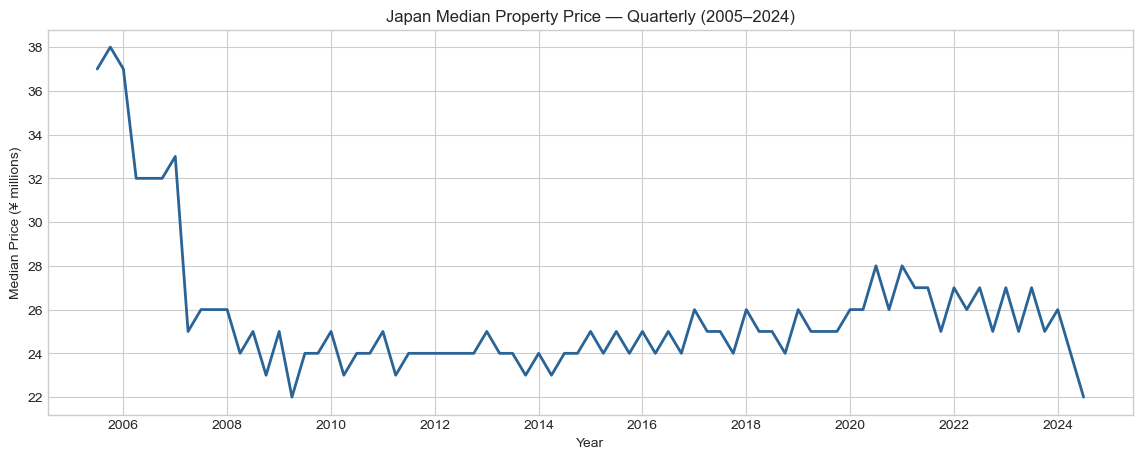

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(ts['ds'], ts['y'] / 1_000_000, 
         color='#2a6496', linewidth=2)
plt.title('Japan Median Property Price — Quarterly (2005–2024)')
plt.xlabel('Year')
plt.ylabel('Median Price (¥ millions)')
plt.savefig('visuals/historical_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- Clear downward trend from 2005 to 2009, followed by stabilization
- Visible quarterly seasonality — prices fluctuate regularly within each year
- Slight upward trend from 2019 to 2021 (post-COVID demand spike)
- Sharp drop in Q3 2024 likely reflects incomplete data for the final quarter

## 4. Prophet Forecast

In [14]:
# Remove last data point - incomplete Q3 2024
ts_train = ts[:-1].copy()

# Scale prices to millions for readability
ts_train['y'] = ts_train['y'] / 1_000_000

# Train Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(ts_train)
print("Model trained!")

# Generate forecast for 12 quarters (3 years)
future = model.make_future_dataframe(periods=12, freq='QS')
forecast = model.predict(future)

print(f"Forecast generated: {len(forecast)} periods")
print(f"\nForecast for 2025–2027:")
forecast_future = forecast[forecast['ds'] > '2024-04-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_future.columns = ['Date', 'Forecast (¥M)', 'Lower bound', 'Upper bound']
print(forecast_future.round(1).to_string(index=False))

10:09:08 - cmdstanpy - INFO - Chain [1] start processing
10:09:09 - cmdstanpy - INFO - Chain [1] done processing


Model trained!
Forecast generated: 88 periods

Forecast for 2025–2027:
      Date  Forecast (¥M)  Lower bound  Upper bound
2024-07-01           27.3         25.9         28.5
2024-10-01           26.4         25.1         27.6
2025-01-01           28.2         27.0         29.5
2025-04-01           26.3         25.1         27.5
2025-07-01           27.3         26.0         28.4
2025-10-01           26.7         25.5         28.0
2026-01-01           28.3         27.0         29.5
2026-04-01           26.4         25.0         27.6
2026-07-01           27.1         25.8         28.5
2026-10-01           26.8         25.4         28.1
2027-01-01           28.0         26.6         29.4
2027-04-01           25.8         24.2         27.3


### 4.1 Forecast Visualization

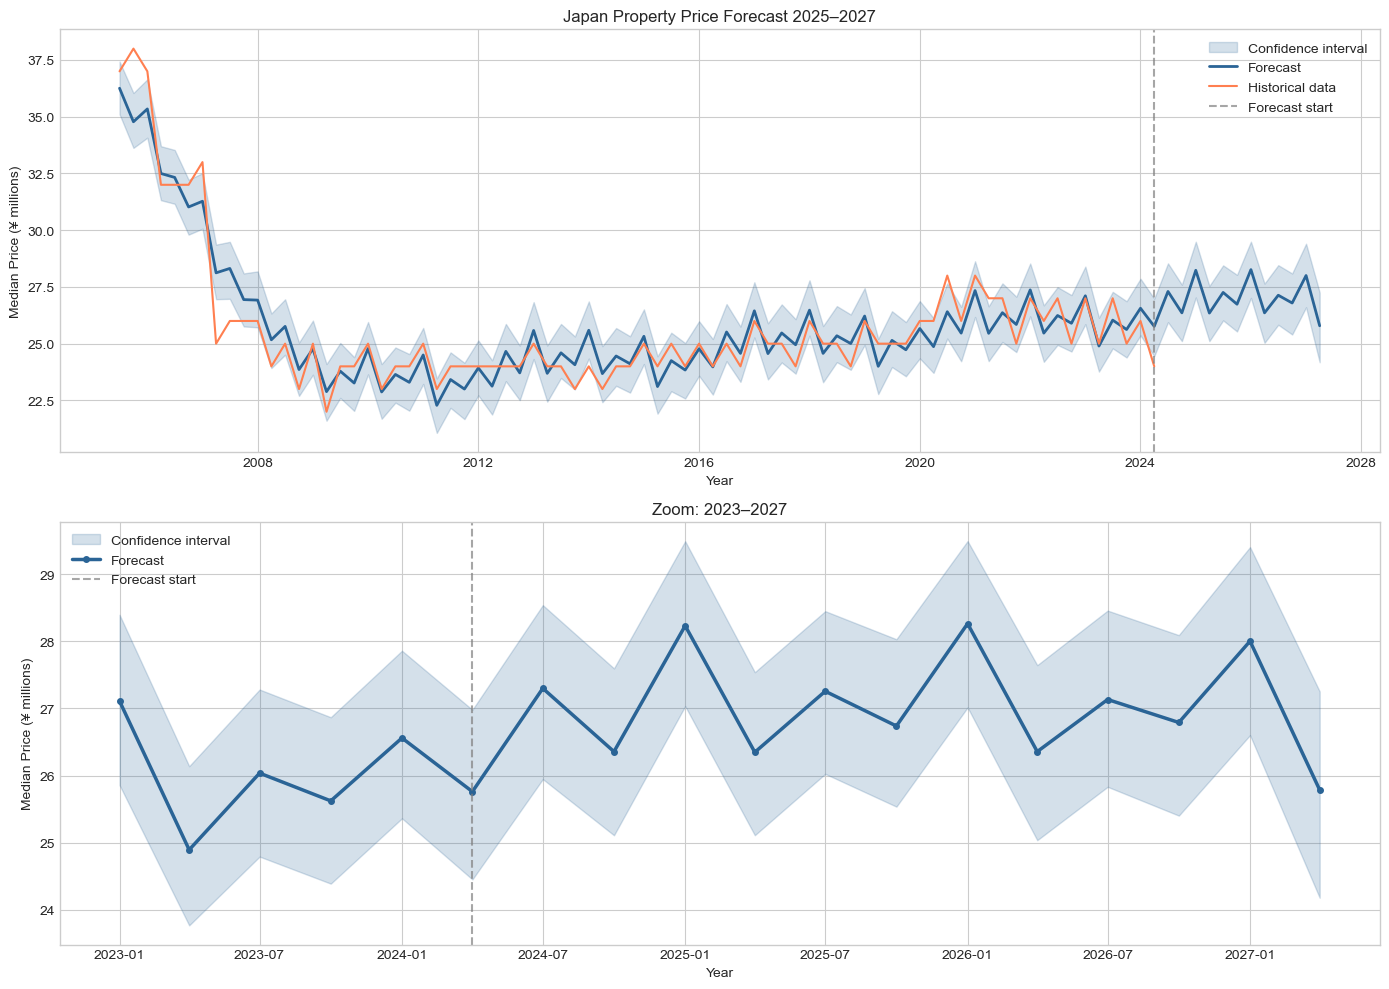

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Plot 1: Full forecast with confidence interval ---
axes[0].fill_between(forecast['ds'], 
                      forecast['yhat_lower'], 
                      forecast['yhat_upper'],
                      alpha=0.2, color='#2a6496', label='Confidence interval')
axes[0].plot(forecast['ds'], forecast['yhat'], 
             color='#2a6496', linewidth=2, label='Forecast')
axes[0].plot(ts_train['ds'], ts_train['y'], 
             color='coral', linewidth=1.5, label='Historical data')
axes[0].axvline(x=pd.Timestamp('2024-04-01'), 
                color='gray', linestyle='--', alpha=0.7, label='Forecast start')
axes[0].set_title('Japan Property Price Forecast 2025–2027')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Price (¥ millions)')
axes[0].legend()

# --- Plot 2: Forecast only (2023-2027 zoom) ---
mask = forecast['ds'] >= '2023-01-01'
axes[1].fill_between(forecast[mask]['ds'],
                      forecast[mask]['yhat_lower'],
                      forecast[mask]['yhat_upper'],
                      alpha=0.2, color='#2a6496', label='Confidence interval')
axes[1].plot(forecast[mask]['ds'], forecast[mask]['yhat'],
             color='#2a6496', linewidth=2.5, marker='o', 
             markersize=4, label='Forecast')
axes[1].axvline(x=pd.Timestamp('2024-04-01'),
                color='gray', linestyle='--', alpha=0.7, label='Forecast start')
axes[1].set_title('Zoom: 2023–2027')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Price (¥ millions)')
axes[1].legend()

plt.tight_layout()
plt.savefig('visuals/price_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- Prophet forecasts a **modest upward trend** in Japanese property prices 
  through 2025–2027, with median prices rising from ¥26M to ¥28M
- **Quarterly seasonality** persists — Q1 consistently shows higher prices 
  than Q2/Q3, reflecting typical Japanese real estate market patterns
- The **confidence interval** remains relatively narrow (±¥1.5M), 
  indicating the model is confident in the stable trend
- The forecast aligns with macroeconomic expectations — growing 
  international interest in Japanese real estate and gradual inflation 
  after decades of deflation support a mild price increase

### 4.2 Regional Forecast: Japan vs Tokyo vs Tokyo Metro Area

How will prices evolve differently across regions?

In [21]:
def make_forecast(data, title):
    ts = (data.groupby('date')['TotalTransactionValue']
              .median()
              .reset_index())
    ts.columns = ['ds', 'y']
    ts = ts.sort_values('ds').reset_index(drop=True)
    ts['y'] = ts['y'] / 1_000_000
    ts = ts[:-1]  # remove last incomplete quarter
    
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    m.fit(ts)
    future = m.make_future_dataframe(periods=12, freq='QS')
    forecast = m.predict(future)
    return ts, forecast

# Prepare regional data
df['date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + 
    ((df['Quarter'] - 1) * 3 + 1).astype(str) + '-01'
)

tokyo = df[df['Prefecture'] == 'Tokyo']
metro = df[df['Prefecture'].isin([
    'Tokyo', 'Kanagawa Prefecture', 
    'Saitama Prefecture', 'Chiba Prefecture'
])]

print("Training models...")
ts_japan, fc_japan = make_forecast(df, 'Japan')
ts_tokyo, fc_tokyo = make_forecast(tokyo, 'Tokyo')
ts_metro, fc_metro = make_forecast(metro, 'Tokyo Metro')
print("Done!")

10:13:05 - cmdstanpy - INFO - Chain [1] start processing


Training models...


10:13:05 - cmdstanpy - INFO - Chain [1] done processing
10:13:05 - cmdstanpy - INFO - Chain [1] start processing
10:13:06 - cmdstanpy - INFO - Chain [1] done processing
10:13:06 - cmdstanpy - INFO - Chain [1] start processing
10:13:06 - cmdstanpy - INFO - Chain [1] done processing


Done!


### 4.3 Regional Price Comparison

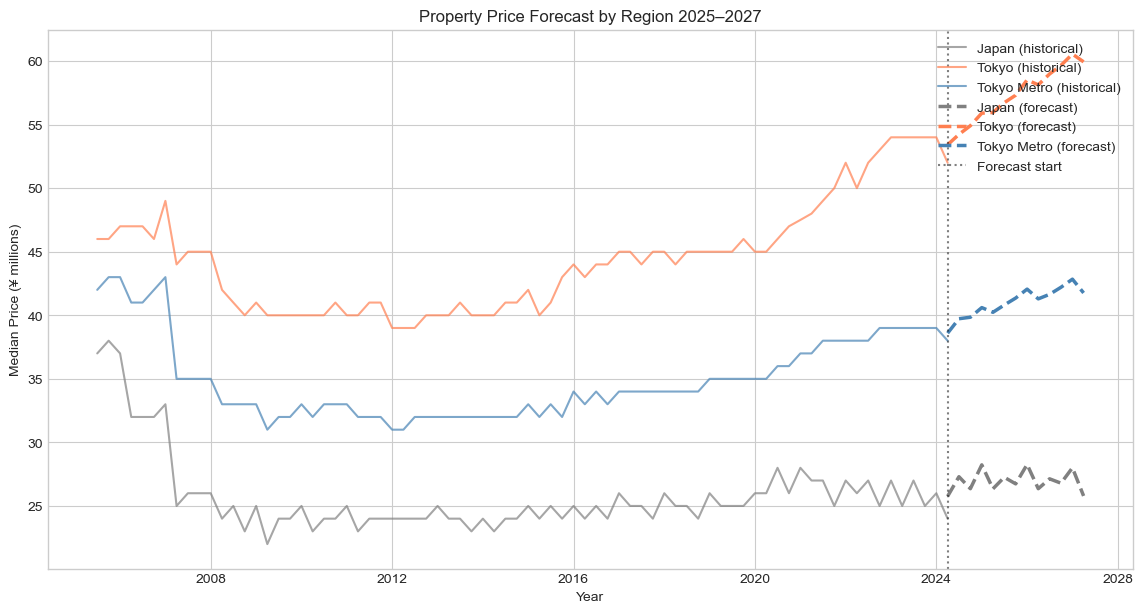

In [24]:
plt.figure(figsize=(14, 7))

cutoff = pd.Timestamp('2024-04-01')

# Historical data
plt.plot(ts_japan['ds'], ts_japan['y'], 
         color='gray', linewidth=1.5, alpha=0.7, label='Japan (historical)')
plt.plot(ts_tokyo['ds'], ts_tokyo['y'], 
         color='coral', linewidth=1.5, alpha=0.7, label='Tokyo (historical)')
plt.plot(ts_metro['ds'], ts_metro['y'], 
         color='steelblue', linewidth=1.5, alpha=0.7, label='Tokyo Metro (historical)')

# Forecasts
mask = fc_japan['ds'] >= cutoff
plt.plot(fc_japan[mask]['ds'], fc_japan[mask]['yhat'],
         color='gray', linewidth=2.5, linestyle='--', label='Japan (forecast)')
plt.plot(fc_tokyo[mask]['ds'], fc_tokyo[mask]['yhat'],
         color='coral', linewidth=2.5, linestyle='--', label='Tokyo (forecast)')
plt.plot(fc_metro[mask]['ds'], fc_metro[mask]['yhat'],
         color='steelblue', linewidth=2.5, linestyle='--', label='Tokyo Metro (forecast)')

plt.axvline(x=cutoff, color='black', linestyle=':', alpha=0.5, label='Forecast start')
plt.title('Property Price Forecast by Region 2025–2027')
plt.xlabel('Year')
plt.ylabel('Median Price (¥ millions)')
plt.legend(loc='upper right')
plt.savefig('visuals/regional_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Tokyo** shows a significantly stronger upward trend than the national 
  average — median prices forecast to reach ¥60M+ by 2027
- **Tokyo Metro area** follows a similar but more moderate growth path, 
  forecast to reach ¥42M by 2027
- **National Japan** remains relatively flat at ¥26–28M — confirming 
  that growth is concentrated in major urban centers
- The gap between Tokyo and the rest of Japan is **widening** — 
  a structural trend driven by urbanization, foreign investment, 
  and limited land supply in the capital
- This regional divergence has important implications for investors: 
  Tokyo remains the safest bet for price appreciation

## 5. Forecast Summary Table

Annual median price forecasts for 2025–2027 across regions.

In [31]:
def annual_forecast(forecast, label):
    future = forecast[forecast['ds'] > '2024-06-01'].copy()
    future['Year'] = future['ds'].dt.year
    annual = future.groupby('Year')[['yhat', 'yhat_lower', 'yhat_upper']].mean().round(1)
    annual.columns = [f'{label} forecast', f'{label} low', f'{label} high']
    return annual

japan_annual = annual_forecast(fc_japan, 'Japan')
tokyo_annual = annual_forecast(fc_tokyo, 'Tokyo')
metro_annual = annual_forecast(fc_metro, 'Metro')

summary = pd.concat([
    japan_annual['Japan forecast'],
    tokyo_annual['Tokyo forecast'],
    metro_annual['Metro forecast']
], axis=1)

print("Annual Price Forecast (¥ millions):")
print(summary.to_string())

Annual Price Forecast (¥ millions):
      Japan forecast  Tokyo forecast  Metro forecast
Year                                                
2024            26.8            54.6            39.8
2025            27.1            56.5            40.7
2026            27.1            58.8            41.8
2027            26.9            60.2            42.3


### Observations

| Region | 2024 | 2025 | 2026 | 2027 |
|--------|------|------|------|------|
| Japan | ¥26.8M | ¥27.1M | ¥27.1M | ¥26.9M |
| Tokyo Metro | ¥39.8M | ¥40.7M | ¥41.8M | ¥42.3M |
| Tokyo | ¥54.6M | ¥56.5M | ¥58.8M | ¥60.2M |

- **Tokyo** is forecast to grow 10% by 2027 — from ¥54.6M to ¥60.2M
- **Tokyo Metro** shows steady growth of ~6% over 3 years
- **National Japan** remains essentially flat — confirming the 
  two-speed nature of the Japanese property market
- By 2027, Tokyo prices will be **2.2x the national median** — 
  the urban-rural divide continues to widen

## 6. Conclusions

### Key Findings

1. **Japan's national market is stable** — median prices forecast 
   to remain around ¥27M through 2027, reflecting demographic 
   headwinds and rural depopulation
2. **Tokyo is in a different league** — prices forecast to reach 
   ¥60M+ by 2027, driven by urbanization, foreign investment, 
   and limited land supply
3. **The urban-rural divide is widening** — by 2027, Tokyo prices 
   will be 2.2x the national median, up from 2.0x in 2024
4. **Quarterly seasonality persists** — Q1 consistently shows 
   higher prices across all regions
5. **Tokyo Metro area** offers a middle ground — growing steadily 
   at ~6% over 3 years, more affordable than central Tokyo

### Limitations & Next Steps
- Prophet extrapolates existing trends — it cannot predict 
  sudden shocks (interest rate hikes, economic crises)
- Adding macroeconomic features (BOJ interest rates, GDP, 
  foreign investment flows) would improve forecast accuracy
- Next notebook: **COVID impact analysis** — how the pandemic 
  reshaped regional property markets

## 7. Saving Results

In [36]:
summary.to_csv('data/price_forecast_2025_2027.csv')
print("Saved: data/price_forecast_2025_2027.csv")
print("\nFinal forecast summary:")
print(summary.to_string())

Saved: data/price_forecast_2025_2027.csv

Final forecast summary:
      Japan forecast  Tokyo forecast  Metro forecast
Year                                                
2024            26.8            54.6            39.8
2025            27.1            56.5            40.7
2026            27.1            58.8            41.8
2027            26.9            60.2            42.3
